# Breast Cancer Diagnosis — Model Training Notebook

Trains 5 classification models on the Breast Cancer Wisconsin (Diagnostic)
dataset, evaluates each with 6 metrics, and saves everything the Streamlit
app needs (`model/*.pkl`, `scaler.pkl`, `feature_names.json`,
`metrics_comparison.csv`, and `test_data.csv`).

## 1. Imports

In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, matthews_corrcoef, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# When running this notebook from model/, PROJECT_DIR is one level up.
BASE_DIR = Path.cwd() if Path.cwd().name == "model" else Path.cwd() / "model"
BASE_DIR.mkdir(exist_ok=True)
PROJECT_DIR = BASE_DIR.parent
print("Saving models to:", BASE_DIR)
print("Saving test_data.csv to:", PROJECT_DIR)

Saving models to: /home/claude/project-folder/model
Saving test_data.csv to: /home/claude/project-folder


## 2. Load the dataset

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "diagnosis"}, inplace=True)
# sklearn encodes 0=malignant, 1=benign — flip so 1=malignant (the
# clinically "positive"/at-risk class), which is more intuitive.
df["diagnosis"] = 1 - df["diagnosis"]

feature_names = [c for c in df.columns if c != "diagnosis"]
print(f"Shape: {df.shape} | Features: {len(feature_names)} | Instances: {len(df)}")
df.head()

Shape: (569, 31) | Features: 30 | Instances: 569


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. Quick EDA

diagnosis
benign       357
malignant    212
Name: count, dtype: int64


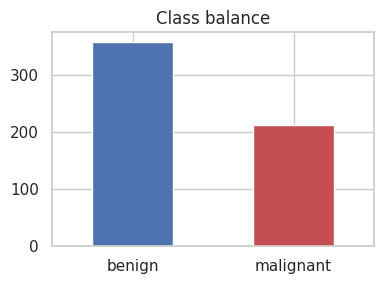

In [3]:
print(df["diagnosis"].value_counts().rename({0: "benign", 1: "malignant"}))

fig, ax = plt.subplots(figsize=(4, 3))
df["diagnosis"].map({0: "benign", 1: "malignant"}).value_counts().plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"]
)
ax.set_title("Class balance")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

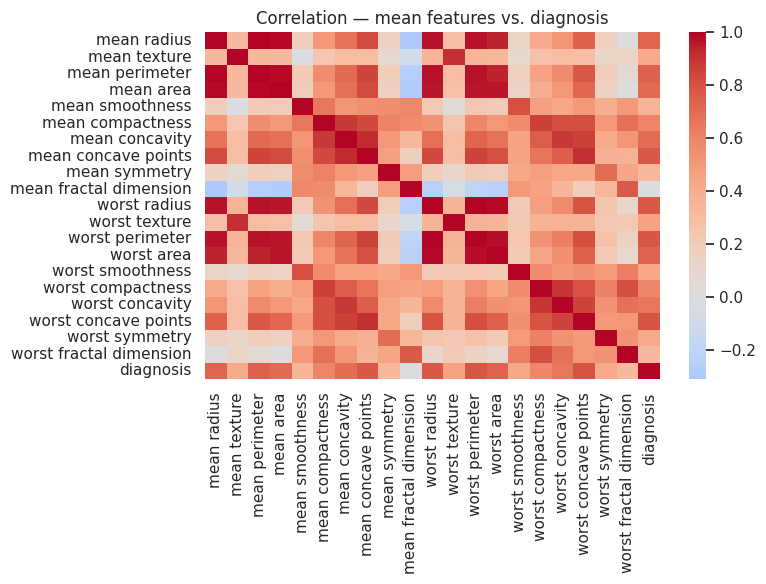

In [4]:
# Correlation heatmap of the "mean" features (first 10 columns) with diagnosis
mean_cols = [c for c in feature_names if not c.endswith(("error", "worst"))]
corr = df[mean_cols + ["diagnosis"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation — mean features vs. diagnosis")
plt.tight_layout()
plt.show()

## 4. Train / test split + scaling

In [5]:
X = df[feature_names]
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


## 5. Define the 5 models

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=RANDOM_STATE
    ),
}
list(models.keys())

['Logistic Regression',
 'Decision Tree',
 'kNN',
 'Naive Bayes',
 'Random Forest (Ensemble)']

## 6. Train, evaluate, and save each model

In [7]:
results = []
confusion_matrices = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "ML Model Name": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
    }
    results.append(metrics)
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    fname = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    with open(BASE_DIR / f"{fname}.pkl", "wb") as f:
        pickle.dump(model, f)

    print(f"{name:28s} | Acc={metrics['Accuracy']:.4f}  AUC={metrics['AUC']:.4f}  "
          f"F1={metrics['F1']:.4f}  MCC={metrics['MCC']:.4f}")

with open(BASE_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(BASE_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

Logistic Regression          | Acc=0.9649  AUC=0.9960  F1=0.9512  MCC=0.9245
Decision Tree                | Acc=0.9211  AUC=0.9448  F1=0.8861  MCC=0.8299
kNN                          | Acc=0.9561  AUC=0.9825  F1=0.9383  MCC=0.9058
Naive Bayes                  | Acc=0.9211  AUC=0.9891  F1=0.8889  MCC=0.8292


Random Forest (Ensemble)     | Acc=0.9649  AUC=0.9944  F1=0.9500  MCC=0.9258


## 7. Comparison table

In [8]:
results_df = pd.DataFrame(results).round(4)
results_df.to_csv(BASE_DIR / "metrics_comparison.csv", index=False)
results_df.set_index("ML Model Name")

,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.9649,0.9960,0.9750,0.9286,0.9512,0.9245
Decision Tree,0.9211,0.9448,0.9459,0.8333,0.8861,0.8299
kNN,0.9561,0.9825,0.9744,0.9048,0.9383,0.9058
Naive Bayes,0.9211,0.9891,0.9231,0.8571,0.8889,0.8292
Random Forest (Ensemble),0.9649,0.9944,1.0000,0.9048,0.9500,0.9258


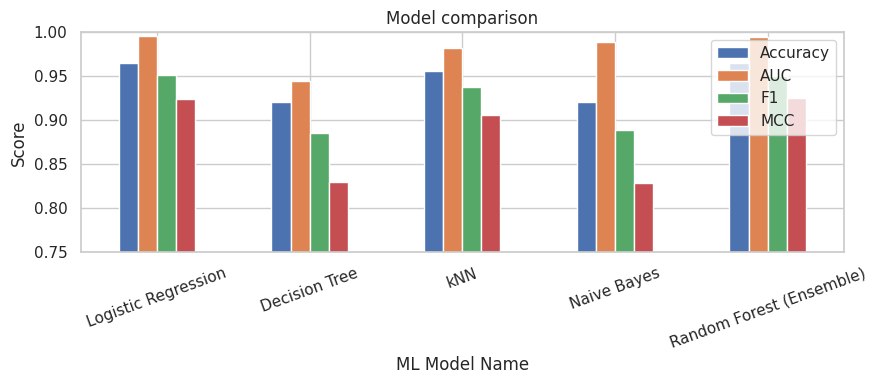

In [9]:
results_df.set_index("ML Model Name")[["Accuracy", "AUC", "F1", "MCC"]].plot(
    kind="bar", figsize=(9, 4), ylim=(0.75, 1.0)
)
plt.title("Model comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 8. Confusion matrices

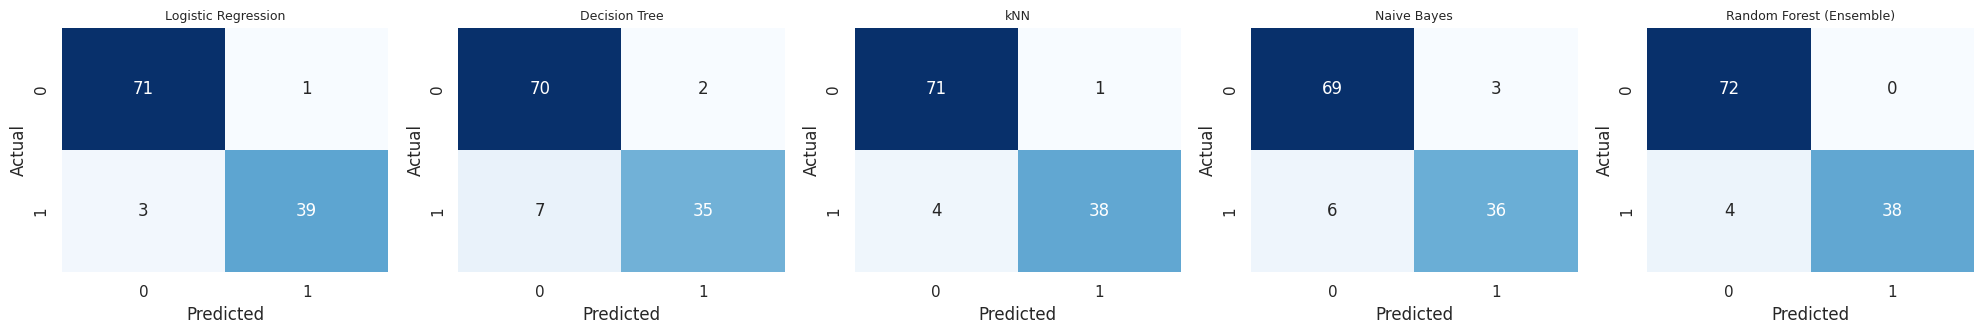

In [10]:
fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 3.5))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 9. Save held-out test data

In [11]:
test_df = X_test.copy()
test_df["diagnosis"] = y_test.values
test_df.to_csv(PROJECT_DIR / "test_data.csv", index=False)
print(f"Saved test_data.csv with {len(test_df)} rows to {PROJECT_DIR}")
test_df.head()

Saved test_data.csv with 114 rows to /home/claude/project-folder


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,15.97,83.74,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523,0
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,27.00,165.30,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849,1
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,19.14,113.10,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960,0
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,30.86,109.50,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353,1
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,41.61,96.69,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675,0
